In [20]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

### 1. Getting Data set ready

In [2]:
heart_disease= pd.read_csv('../HEART_DISEASE_PROJECT/data/heart-disease.csv')

In [3]:
#check the first 5 rows of the dataframe
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Our goal here is to build a machine learning model on all of the columns except `target` to predict `target`.

In [4]:
X= heart_disease.drop("target", axis=1)
y= heart_disease["target"]

In [5]:
print("X.shape", X.shape)
print("y.shape", y.shape)


X.shape (303, 13)
y.shape (303,)


- Training data is where the model learns.
- Test data is where the model proves it didn’t just memorize.

In [6]:
# Split the dataset into training and testing sets.
# X_train and y_train are used to train the model (learn patterns).
# X_test and y_test are kept aside to evaluate how well the model performs on unseen data.
# test_size=0.2 means 20% of the data is used for testing.
# random_state=42 ensures the split is reproducible (same split every time).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

- X_train  , y_train ≈ 80% of the rows
- X_test, y_test ≈ 20% of the rows
- Model sees the same features during training and testing.

### 2. Preparing a machine learning model

##### why we chose RandomForestClassifier
- The model creates many decision trees.
- Each tree trains on a random subset of rows (bootstrapping).
- At each split, the tree looks at a random subset of features.
- Each tree predicts a class.
- The forest returns the most voted class.

In [8]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

### 3.Fitting a model and making predictions

- Fitting is learning. Not remembering answers, but learning how to get them 
- To learn patterns from data that map inputs (X) to outputs (y).

- The target of predictions: to apply what was learned to new, unseen data.

In [9]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

This output shows the default settings that control how the Random Forest builds and trains its trees, not how well the model performs.

In [10]:
#To check how well the model generalizes by comparing these predictions (y_pred) with the true labels (y_test).
y_pred= clf.predict(X_test) 

### 4.Evaluating a model's prediction using Score

The model’s accuracy is computed using the score() method on X_train, y_train and X_test, y_test.

In [11]:
clf.score(X_train, y_train)

1.0

In [25]:
np.random.seed(42)
clf.score(X_test, y_test)

0.8524590163934426

- The model achieves 100% accuracy on the training data but only ~85.2% accuracy on the test data, which indicates overfitting.
- The model learned the training data extremely well (possibly memorized it), but its performance drops on unseen data, meaning generalization is not perfect.

### Experimenting with different classification models

In [26]:
# Import LinearSVC from sklearn's svm module
from sklearn.svm import LinearSVC
# Import KNeighborsClassifier from sklearn's neighbors module
from sklearn.neighbors import KNeighborsClassifier
# Import SVC from sklearn's svm module
from sklearn.svm import SVC
# Import LogisticRegression from sklearn's linear_model module
from sklearn.linear_model import LogisticRegression

In [27]:
models = {"LinearSVC": LinearSVC(),
          "KNN": KNeighborsClassifier(),
          "SVC": SVC(),
          "LogisticRegression": LogisticRegression(),
          "RandomForestClassifier": RandomForestClassifier()}

# Create an empty dictionary called results
results = {}

In [28]:
np.random.seed(42)
for model_name, model in models.items():
    model.fit(X_train, y_train)
    results[model_name] = model.score(X_test, y_test    )

# View the results
results

c:\Users\maria\OneDrive\Desktop\Heart_Disease_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'LinearSVC': 0.8688524590163934,
 'KNN': 0.6885245901639344,
 'SVC': 0.7049180327868853,
 'LogisticRegression': 0.8852459016393442,
 'RandomForestClassifier': 0.8360655737704918}

<Axes: >

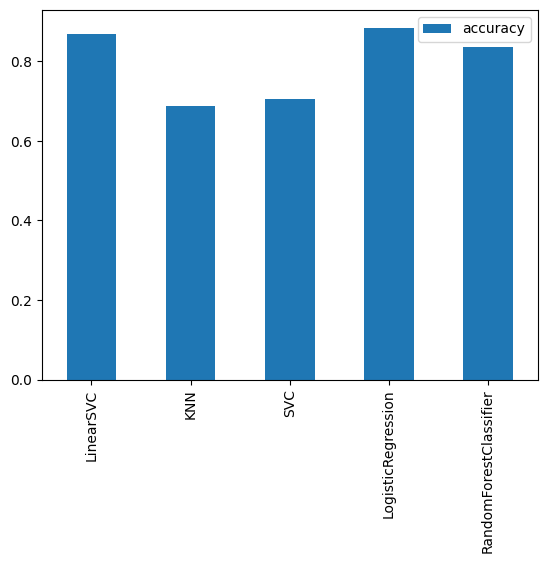

In [29]:
# Create a pandas dataframe with the data as the values of the results dictionary,
# the index as the keys of the results dictionary and a single column called accuracy.
# Be sure to save the dataframe to a variable.
results_df = pd.DataFrame(results.values(), 
                          results.keys(), 
                          columns=["accuracy"])

# Create a bar plot of the results dataframe using plot.bar()
results_df.plot.bar()

In [30]:
results_df

,accuracy
LinearSVC,0.868852
KNN,0.688525
SVC,0.704918
LogisticRegression,0.885246
RandomForestClassifier,0.836066


Among the tested models, Logistic Regression (88.5%) and LinearSVC (86.9%) achieved the highest accuracy, making them the best performers on this dataset. Random Forest (83.6%) showed solid performance but underperformed compared to linear models, while SVC (70.5%) and KNN (68.9%) were less effective.

### 5.Hyperparameter Tuning using RandomizedSearch

Hyperparameter tuning is the process of adjusting a model’s configuration settings to improve its performance and generalization on unseen data.

- GridSearch → (Few parameters), RandomizedSearch → (Many parameters or wide ranges) are methods for hyperparameter tuning: they help you find the best model settings without guessing.
- It tests every possible combination of hyperparameters you define.
- It tests a random subset of combinations for a fixed number of trials.

In [31]:
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

#C is the regularization strength parameter. It controls the trade-off between achieving a low training error and a low testing error (generalization).
# A smaller C value means stronger regularization, which can help prevent overfitting.
# A larger C value means weaker regularization, allowing the model to fit the training data more closely.
#np.logspace(-4, 4, 20) generates 20 values between 10⁻⁴ (0.0001) and 10⁴ (10000) on a logarithmic scale.
# The solver parameter specifies the algorithm to use for optimization. "liblinear" is a good choice for small datasets and is suitable for binary classification tasks.


In [32]:
np.random.seed(42)
from sklearn.model_selection import RandomizedSearchCV
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(), #The model you want to tune.
                                param_distributions=log_reg_grid,# The hyperparameter(s) you want to try out.
                                cv=5,# The number of folds to use for cross-validation.
                                n_iter=5,# The number of different combinations to try.
                                verbose=1) #The verbosity level, which controls how much information is printed during the search.
rs_log_reg.fit(X_train, y_train) 

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold

Once `RandomizedSearchCV` has finished, we can find the best hyperparmeters it found using the `best_params_` attributes.

In [33]:
# Find the best parameters:
###
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

above we let it to test on  random  param "C": np.logspace(-4, 4, 20), and here it results that the best param for c is 0.23

In [34]:
rs_log_reg.score(X_test, y_test)

0.8852459016393442

### 6.Hypertuning using GridSearchCV

In [36]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
log_reg_grid = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear"]
}

# Set random seed for reproducibility
np.random.seed(42)
# Grid Search
gs_log_reg = GridSearchCV(
    estimator=LogisticRegression(),   
    param_grid=log_reg_grid,           
    cv=5,                              
    verbose=1 
)
gs_log_reg.fit(X_train, y_train)

print("gs_log_reg.best_params:", gs_log_reg.best_params_)

# Evaluate on test data
print("gs_log_reg.score(X_test, y_test):", gs_log_reg.score(X_test, y_test))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
gs_log_reg.best_params: {'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}
gs_log_reg.score(X_test, y_test): 0.8852459016393442


### 7.Evaluating the model using differenct Metrics

Confusion matrix, Cross-validation, Precision, Recall, F1 score, Classification report, ROC Curve, Area Under Curve (AUC)

In [42]:
clf= LogisticRegression(**rs_log_reg.best_params_)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....7214690901212)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class o

import the relative Scikit-Learn methods for each of the classification evaluation metrics we're after.

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay


In [47]:
y_pred= clf.predict(X_test)

In [49]:
confusion_matrix(y_test, y_pred)
#The confusion matrix shows that the model correctly classified most samples (25 true negatives and 29 true positives)
# with only a few misclassifications (4 false positives and 3 false negatives).


array([[25,  4],
       [ 3, 29]])

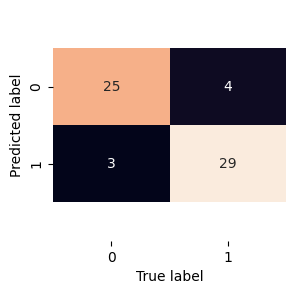

In [52]:
#visual confusion matrix
import seaborn as sns
def plot_confusion_matrix(y_test, y_pred):
    fig, ax = plt.subplots(figsize=(3,3))
    ax= sns.heatmap(confusion_matrix(y_test, y_pred),
                   annot=True,
                   cbar=False,)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    bottom, top =ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    
plot_confusion_matrix(y_test, y_pred)    

**Precision:**
Precision = **TP / (TP + FP)** → measures how many predicted positives are actually correct.

**Recall:**
Recall = **TP / (TP + FN)** → measures how many actual positives the model successfully detected.


In [54]:
precision_score(y_test, y_pred)

0.8787878787878788

In [55]:
recall_score(y_test, y_pred)

0.90625

In [56]:
f1_score(y_test, y_pred)

0.8923076923076924

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



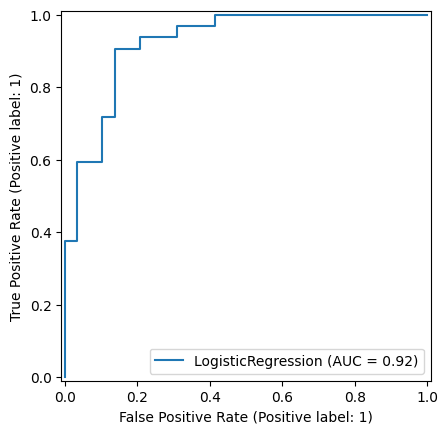

In [58]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(clf, X_test, y_test)

plt.show()


In [59]:
# Import cross_val_score from sklearn's model_selection module
from sklearn.model_selection import cross_val_score
cross_val_acc = np.mean(cross_val_score(clf,
                                        X,
                                        y,
                                        scoring="accuracy",
                                        cv=5))

cross_val_acc

np.float64(0.8479781420765027)

In [60]:
#Find the cross-validated precision
cross_val_prec = np.mean(cross_val_score(clf,
                                        X,
                                        y,
                                        scoring="precision",
                                        cv=5))

cross_val_prec

np.float64(0.8215873015873015)

In [62]:
# Find the cross-validated recall
cross_val_rec = np.mean(cross_val_score(clf,
                                        X,
                                        y,
                                        scoring="recall",
                                        cv=5))
cross_val_rec

np.float64(0.9272727272727274)

In [63]:
# Find the cross-validated F1 score
cross_val_f1 = np.mean(cross_val_score(clf,
                                        X,
                                        y,
                                        scoring="f1",
                                        cv=5))
cross_val_f1

np.float64(0.8705403543192143)

### 8.Exporting and importing a trained model

In [65]:
from joblib import dump, load


In [66]:
dump(clf, "clf_model.joblib")

['clf_model.joblib']